# Test of InstaSHAP

In [1]:
import torch
import numpy as np
import copy
import os, time
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

from sian.models import TrainingArgs

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.instashap import surrogate, InstaSHAP, InstaSHAP_classifier
from src.dataloader import CustomTreeDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/opt/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step1: Prepare the data
use the bike_sharing data as in the paper https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [2]:
data_base_path = "../data/"

In [3]:
print("Initializing Custom Dataset...")
dataset_obj = CustomTreeDataset(data_base_path, seed=37)
dataset_obj.shuffle_and_split_trnval()
print(f"Dataset ready. X shape: {dataset_obj.trnX.shape}, Y shape: {dataset_obj.trnY.shape}")

Initializing Custom Dataset...
Dataset ready. X shape: (325366, 18), Y shape: (325366, 1)


/Users/bufeng/Desktop/Seminar/InstaSHAP_implement/src/dataloader.py:204: RuntimeWarning: divide by zero encountered in matmul
  all_simple_soils = np.matmul(all_data_array[:, 14:54], soil_remapping_tensor)
/Users/bufeng/Desktop/Seminar/InstaSHAP_implement/src/dataloader.py:204: RuntimeWarning: overflow encountered in matmul
  all_simple_soils = np.matmul(all_data_array[:, 14:54], soil_remapping_tensor)
/Users/bufeng/Desktop/Seminar/InstaSHAP_implement/src/dataloader.py:204: RuntimeWarning: invalid value encountered in matmul
  all_simple_soils = np.matmul(all_data_array[:, 14:54], soil_remapping_tensor)


In [4]:
# Prepare DataLoaders
batch_size = 256

X_train_tensor = torch.FloatTensor(dataset_obj.trnX)
y_train_tensor = torch.LongTensor(dataset_obj.trnY.squeeze())
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val_tensor = torch.FloatTensor(dataset_obj.valX)
y_val_tensor = torch.LongTensor(dataset_obj.valY.squeeze())
# Note: InstaSHAP forward needs 'S' (mask), but for accuracy evaluation we use S=1 (all features present)

num_features = dataset_obj.trnX.shape[1]
num_classes = len(np.unique(dataset_obj.trnY))
print(f"Features: {num_features}, Classes: {num_classes}")

Features: 18, Classes: 7


In [5]:
def evaluate_accuracy(model, X, y, interactions_len_list):
    model.eval()
    model.to(device)
    X = X.to(device)
    y = y.to(device)
    
    # Create a mask S of all 1s (shape: Batch x Num_Interactions)
    # The transform_matrix inside the model maps S_features to S_interactions
    # But wait, model.forward(x, S) expects S to be the FEATURE mask (Batch x Num_Features)
    # The model internally transforms it.
    S_full_features = torch.ones((X.shape[0], num_features)).to(device)
    
    with torch.no_grad():
        logits = model(X, S_full_features)
        preds = torch.argmax(logits, dim=1)
        
    acc = accuracy_score(y.cpu().numpy(), preds.cpu().numpy())
    return acc

## No interaction SHAP

In [6]:
interactions_no_inter = [[]] + [[i] for i in range(num_features)]
transform_matrix_no_inter = torch.eye(num_features)

model_no_inter = InstaSHAP_classifier(
    interactions_no_inter, 
    transform_matrix_no_inter, 
    num_classes=num_classes, 
    device=device
)

start_time = time.time()
model_no_inter.train_instaSHAP(train_loader, num_epochs=10, lr=1e-3)
time_no_inter = time.time() - start_time
print(f"Training Time (No Inter): {time_no_inter:.2f}s")

acc_no_inter = evaluate_accuracy(model_no_inter, X_val_tensor, y_val_tensor, interactions_no_inter)
print(f"Validation Accuracy (No Interactions): {acc_no_inter*100:.2f}%")

Epoch 1: 100%|██████████| 1271/1271 [00:02<00:00, 438.78it/s]


Epoch 1, Loss: 24.5048


Epoch 2: 100%|██████████| 1271/1271 [00:02<00:00, 448.49it/s]


Epoch 2, Loss: 1.6915


Epoch 3: 100%|██████████| 1271/1271 [00:02<00:00, 443.74it/s]


...

Epoch 8, Loss: 1.6005


Epoch 9: 100%|██████████| 1271/1271 [00:02<00:00, 434.13it/s]


Epoch 9, Loss: 1.6221


Epoch 10: 100%|██████████| 1271/1271 [00:02<00:00, 440.60it/s]

Epoch 10, Loss: 1.6379
Training Time (No Inter): 29.60s
Validation Accuracy (No Interactions): 50.00%


## with interaction

In [7]:
dataset_obj.get_task_type()

'multiclass_classification'

In [8]:
results_path = "../results/"
exp_folder = results_path+'_'+ "demo" +'_simple_testing/TreeOver'
os.makedirs(exp_folder, exist_ok=True)

mlp_args = TrainingArgs(batch_size=256, number_of_epochs=20, learning_rate=1e-3, device=device) 
mlp_args.model_config.net_name = "MLP"
mlp_args.model_config.sizes = [-1, 128, 256, 128, -1]
mlp_args.model_config.is_masked = True  
mlp_args.saving_settings.exp_folder = exp_folder
 
my_surrogate = surrogate(mlp_args=mlp_args, dataset_obj=dataset_obj, max_number_of_rounds=18, order=2, output_type='classification')
interactions = my_surrogate.get_interactions(device=device)
transform_matrix = my_surrogate.get_transform_matrix()

print(f"\nFound interactions: {interactions}")

trnX trnY (325366, 18) (325366, 1)
Epoch 0
MSE for train and val: 1.9520083973264433, 1.938969267557167
--- 1.970 seconds in epoch ---
Epoch 1
MSE for train and val: 1.8306125385330945, 1.818196089146095
--- 1.838 seconds in epoch ---
Epoch 2
MSE for train and val: 1.7653305257567458, 1.751871491700606
--- 1.784 seconds in epoch ---
Epoch 3
MSE for train and val: 1.7212352989774706, 1.7072455971227234
--- 1.772 seconds in epoch ---
Epoch 4
MSE for train and val: 1.6592465685395985, 1.6472452772353205
--- 1.771 seconds in epoch ---
Epoch 5
MSE for train and val: 1.6508852964799143, 1.6388212844769405
--- 1.762 seconds in epoch ---
Epoch 6
MSE for train and val: 1.6538946639738428, 1.6448906508908272
--- 1.781 seconds in epoch ---
Epoch 7
MSE for train and val: 1.6006053364157287, 1.5921883675088333
--- 1.772 seconds in epoch ---
Epoch 8
MSE for train and val: 1.5639914815406974, 1.5513998616511075
--- 1.748 seconds in epoch ---
Epoch 9
MSE for train and val: 1.5454598720781483, 1.535425

Exception: not implemented yet, but idk just make it like regression for now

## Step2: Train Mask MLP
find the interactions

trnval_shuffle_seed: 0
trnX trnY (9732, 13) (9732, 1)
Epoch 0
MSE for train and val: 2.355665697678027, 2.27505714482244
--- 0.255 seconds in epoch ---
Epoch 1
MSE for train and val: 1.8162112499534044, 1.8195194626205389
--- 0.203 seconds in epoch ---
Epoch 2
MSE for train and val: 1.388670463490502, 1.3407627974464302
--- 0.246 seconds in epoch ---
Epoch 3
MSE for train and val: 0.875050813642599, 0.8435969302622178
--- 0.211 seconds in epoch ---
Epoch 4
MSE for train and val: 0.7977436273064927, 0.7845960238239407
--- 0.199 seconds in epoch ---
Epoch 5
MSE for train and val: 0.5932342919279784, 0.5822805882692319
--- 0.200 seconds in epoch ---
Epoch 6
MSE for train and val: 0.507162422592918, 0.4978691381778615
--- 0.201 seconds in epoch ---
Epoch 7
MSE for train and val: 0.559006805877044, 0.5461161167496581
--- 0.199 seconds in epoch ---
Epoch 8
MSE for train and val: 0.5316112078264864, 0.5372500764941489
--- 0.191 seconds in epoch ---
Epoch 9
MSE for train and val: 0.39767828473

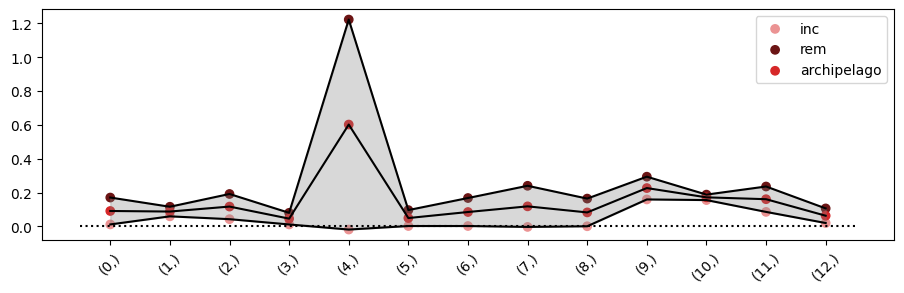

new_selections [(4,)]
selections [(4,)]
new_cands []
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (9,), (10,), (11,), (12,)]
0.12158703804016113 seconds
nr 1
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


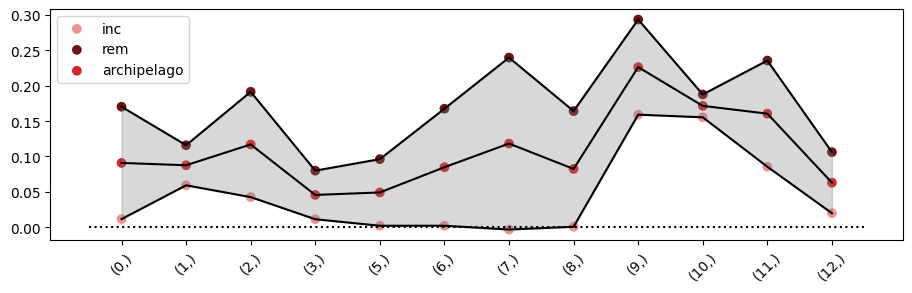

new_selections [(9,)]
selections [(4,), (9,)]
new_cands [(4, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (10,), (11,), (12,), (4, 9)]
0.2258927822113037 seconds
nr 2
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


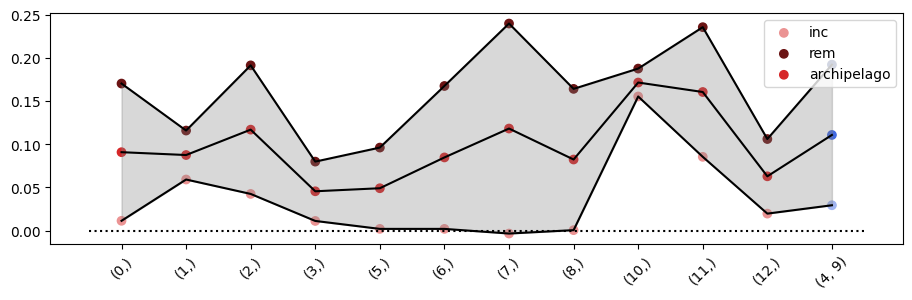

new_selections [(10,)]
selections [(4,), (9,), (10,)]
new_cands [(4, 9), (4, 10), (9, 10)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (11,), (12,), (4, 9), (4, 10), (9, 10)]
0.3338198661804199 seconds
nr 3
archipelago_tensor (13, 2, 4171)
semitruth torch.Size([4171, 1])


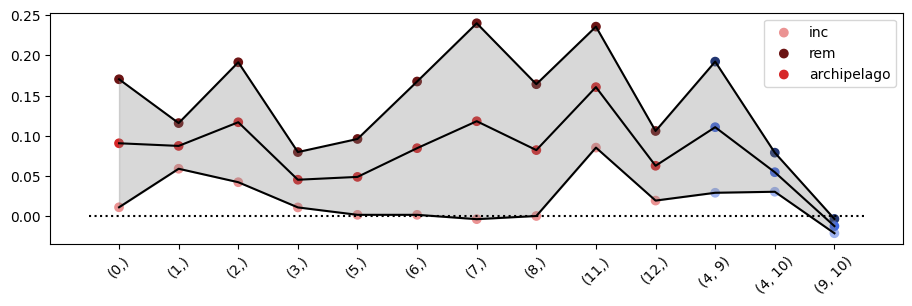

new_selections [(11,)]
selections [(4,), (9,), (10,), (11,)]
new_cands [(4, 9), (4, 10), (4, 11), (9, 10), (9, 11), (10, 11)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11)]
0.5103230476379395 seconds
nr 4
archipelago_tensor (15, 2, 4171)
semitruth torch.Size([4171, 1])


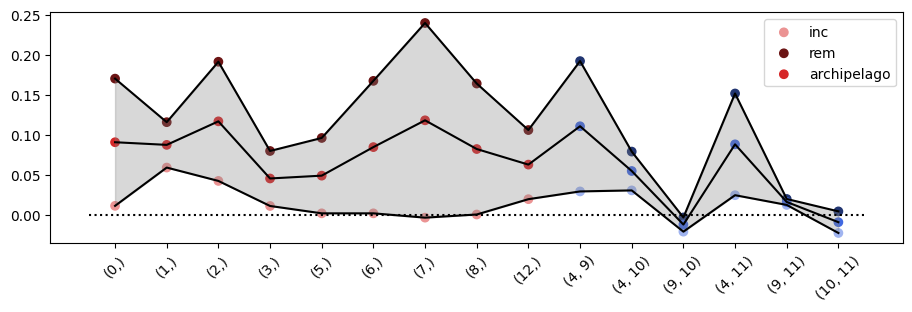

new_selections [(7,)]
selections [(4,), (9,), (10,), (11,), (7,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (9, 10), (9, 11), (7, 9), (10, 11), (7, 10), (7, 11)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (4, 7), (7, 9), (7, 10), (7, 11)]
0.6831648349761963 seconds
nr 5
archipelago_tensor (18, 2, 4171)
semitruth torch.Size([4171, 1])


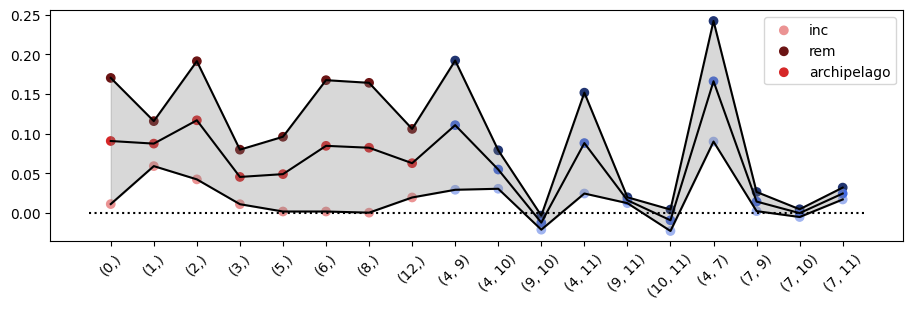

new_selections [(4, 7)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (9, 10), (9, 11), (7, 9), (10, 11), (7, 10), (7, 11)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11)]
0.8350028991699219 seconds
nr 6
archipelago_tensor (17, 2, 4171)
semitruth torch.Size([4171, 1])


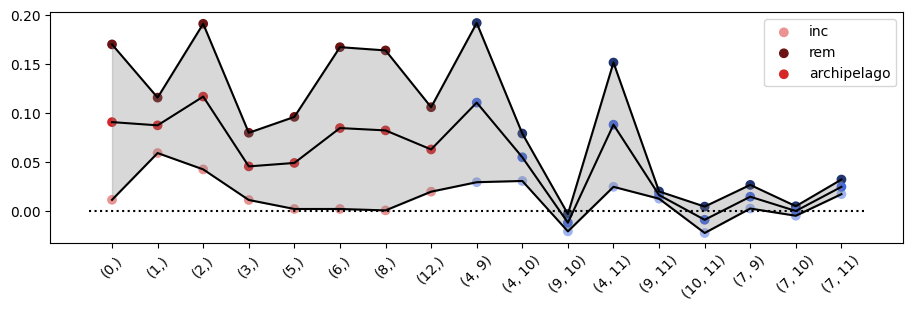

new_selections [(2,)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (9, 10), (9, 11), (7, 9), (2, 9), (10, 11), (7, 10), (2, 10), (7, 11), (2, 11), (2, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 4), (2, 9), (2, 10), (2, 11), (2, 7)]
0.9876260757446289 seconds
nr 7
archipelago_tensor (21, 2, 4171)
semitruth torch.Size([4171, 1])


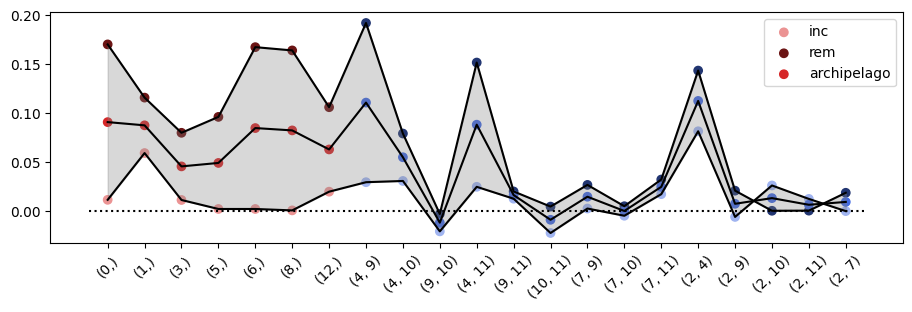

new_selections [(2, 4)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (9, 10), (9, 11), (7, 9), (2, 9), (10, 11), (7, 10), (2, 10), (7, 11), (2, 11), (2, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7)]
1.1557750701904297 seconds
nr 8
archipelago_tensor (20, 2, 4171)
semitruth torch.Size([4171, 1])


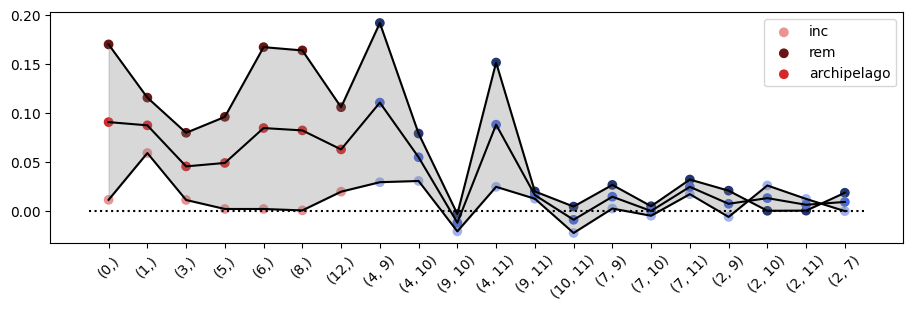

new_selections [(4, 9)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (9, 10), (9, 11), (7, 9), (2, 9), (10, 11), (7, 10), (2, 10), (7, 11), (2, 11), (2, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7)]
1.3235468864440918 seconds
nr 9
archipelago_tensor (19, 2, 4171)
semitruth torch.Size([4171, 1])


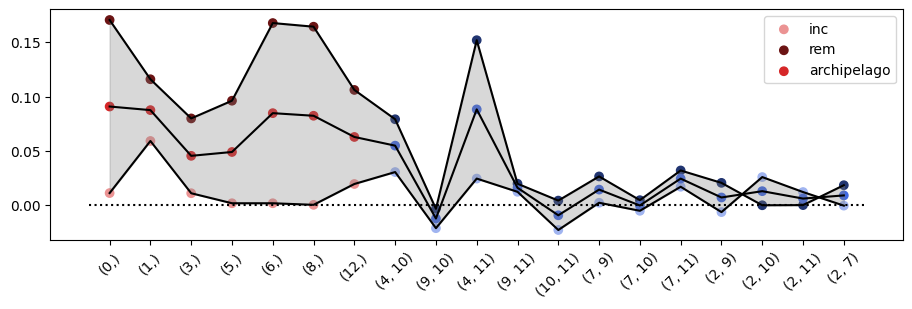

new_selections [(0,)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (10, 11), (7, 10), (2, 10), (0, 10), (7, 11), (2, 11), (0, 11), (2, 7), (0, 7), (0, 2)]
candidates [(1,), (3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 4), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2)]
1.4772486686706543 seconds
nr 10
archipelago_tensor (24, 2, 4171)
semitruth torch.Size([4171, 1])


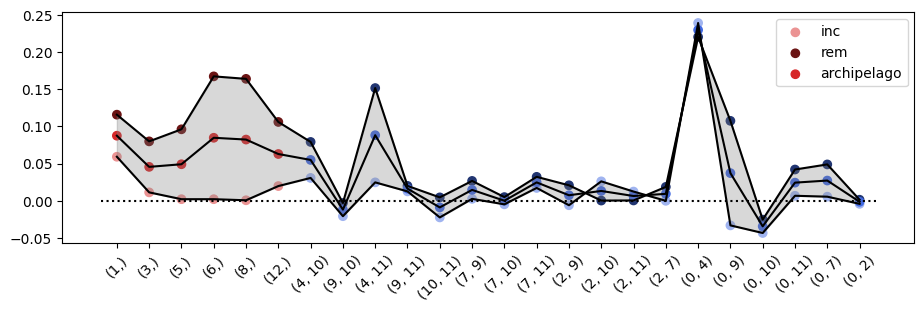

new_selections [(0, 4)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (10, 11), (7, 10), (2, 10), (0, 10), (7, 11), (2, 11), (0, 11), (2, 7), (0, 7), (0, 2)]
candidates [(1,), (3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2)]
1.6617228984832764 seconds
nr 11
archipelago_tensor (23, 2, 4171)
semitruth torch.Size([4171, 1])


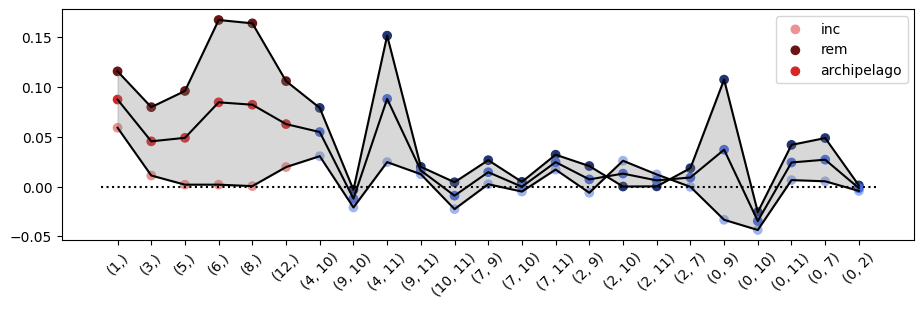

new_selections [(4, 11)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (10, 11), (7, 10), (2, 10), (0, 10), (7, 11), (2, 11), (0, 11), (2, 7), (0, 7), (0, 2)]
candidates [(1,), (3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2)]
1.8850948810577393 seconds
nr 12
archipelago_tensor (22, 2, 4171)
semitruth torch.Size([4171, 1])


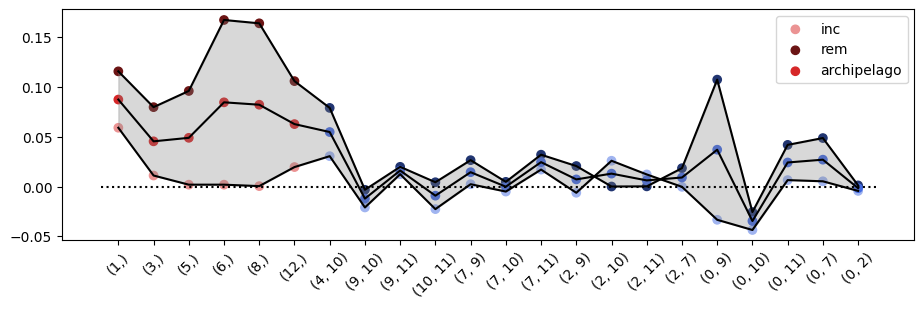

new_selections [(1,)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (7, 11), (2, 11), (0, 11), (1, 11), (2, 7), (0, 7), (1, 7), (0, 2), (1, 2), (0, 1)]
candidates [(3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 4), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1)]
2.0694189071655273 seconds
nr 13
archipelago_tensor (28, 2, 4171)
semitruth torch.Size([4171, 1])


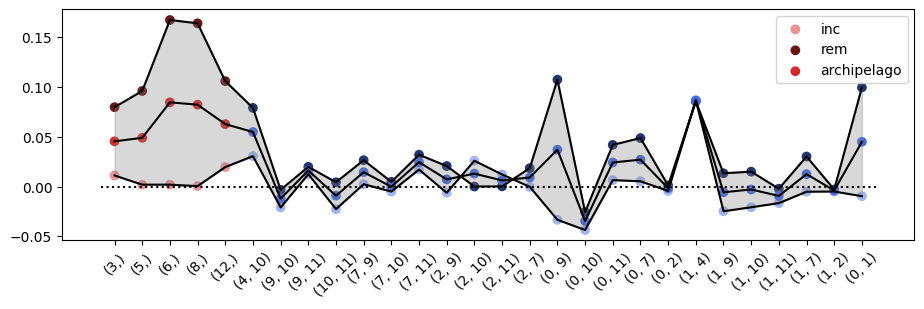

new_selections [(1, 4)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (7, 11), (2, 11), (0, 11), (1, 11), (2, 7), (0, 7), (1, 7), (0, 2), (1, 2), (0, 1)]
candidates [(3,), (5,), (6,), (8,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1)]
2.2875521183013916 seconds
nr 14
archipelago_tensor (27, 2, 4171)
semitruth torch.Size([4171, 1])


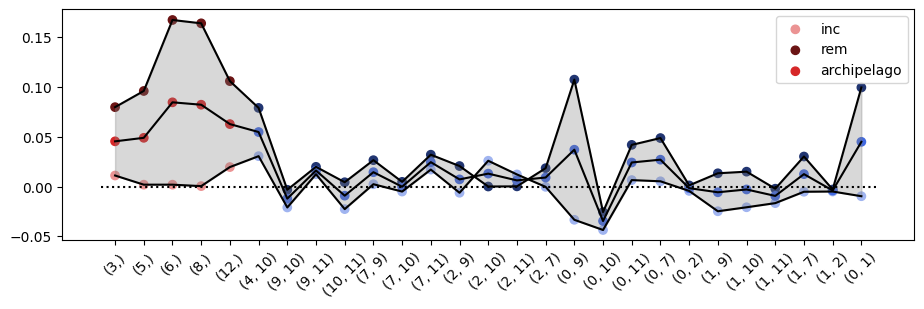

new_selections [(6,)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4), (6,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (4, 6), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (6, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (6, 10), (7, 11), (2, 11), (0, 11), (1, 11), (6, 11), (2, 7), (0, 7), (1, 7), (6, 7), (0, 2), (1, 2), (2, 6), (0, 1), (0, 6), (1, 6)]
candidates [(3,), (5,), (8,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1), (4, 6), (6, 9), (6, 10), (6, 11), (6, 7), (2, 6), (0, 6), (1, 6)]
2.4971678256988525 seconds
nr 15
archipelago_tensor (34, 2, 4171)
semitruth torch.Size([4171, 1])


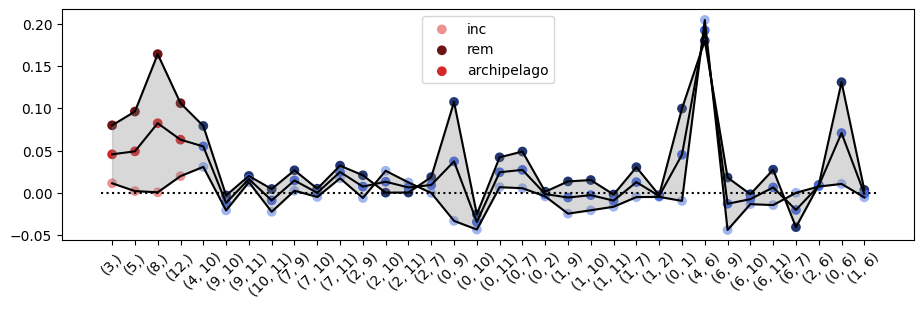

new_selections [(4, 6)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4), (6,), (4, 6)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (4, 6), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (6, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (6, 10), (7, 11), (2, 11), (0, 11), (1, 11), (6, 11), (2, 7), (0, 7), (1, 7), (6, 7), (0, 2), (1, 2), (2, 6), (0, 1), (0, 6), (1, 6)]
candidates [(3,), (5,), (8,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1), (6, 9), (6, 10), (6, 11), (6, 7), (2, 6), (0, 6), (1, 6)]
2.776073932647705 seconds
nr 16
archipelago_tensor (33, 2, 4171)
semitruth torch.Size([4171, 1])


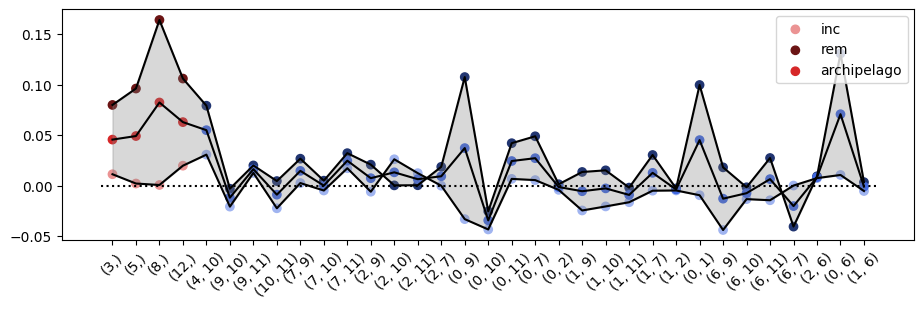

new_selections [(8,)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4), (6,), (4, 6), (8,)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (4, 6), (4, 8), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (6, 9), (8, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (6, 10), (8, 10), (7, 11), (2, 11), (0, 11), (1, 11), (6, 11), (8, 11), (2, 7), (0, 7), (1, 7), (6, 7), (7, 8), (0, 2), (1, 2), (2, 6), (2, 8), (0, 1), (0, 6), (0, 8), (1, 6), (1, 8), (6, 8)]
candidates [(3,), (5,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1), (6, 9), (6, 10), (6, 11), (6, 7), (2, 6), (0, 6), (1, 6), (4, 8), (8, 9), (8, 10), (8, 11), (7, 8), (2, 8), (0, 8), (1, 8), (6, 8)]
3.029024124145508 seconds
nr 17
archipelago_tensor (41, 2, 4171)
semitruth torch.Size([4171, 1])


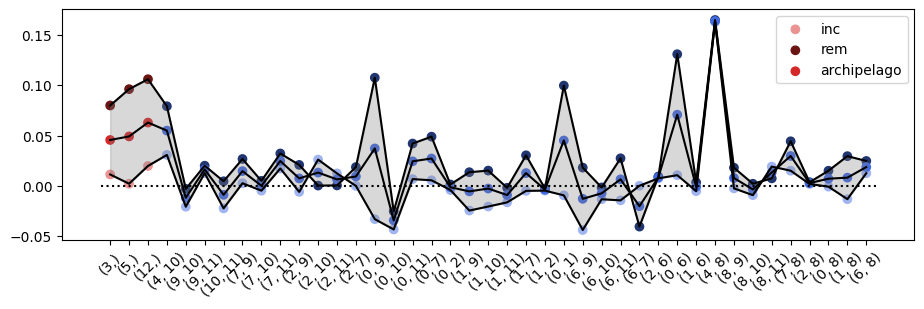

new_selections [(4, 8)]
selections [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4), (6,), (4, 6), (8,), (4, 8)]
new_cands [(4, 9), (4, 10), (4, 11), (4, 7), (2, 4), (0, 4), (1, 4), (4, 6), (4, 8), (9, 10), (9, 11), (7, 9), (2, 9), (0, 9), (1, 9), (6, 9), (8, 9), (10, 11), (7, 10), (2, 10), (0, 10), (1, 10), (6, 10), (8, 10), (7, 11), (2, 11), (0, 11), (1, 11), (6, 11), (8, 11), (2, 7), (0, 7), (1, 7), (6, 7), (7, 8), (0, 2), (1, 2), (2, 6), (2, 8), (0, 1), (0, 6), (0, 8), (1, 6), (1, 8), (6, 8)]
candidates [(3,), (5,), (12,), (4, 10), (9, 10), (9, 11), (10, 11), (7, 9), (7, 10), (7, 11), (2, 9), (2, 10), (2, 11), (2, 7), (0, 9), (0, 10), (0, 11), (0, 7), (0, 2), (1, 9), (1, 10), (1, 11), (1, 7), (1, 2), (0, 1), (6, 9), (6, 10), (6, 11), (6, 7), (2, 6), (0, 6), (1, 6), (8, 9), (8, 10), (8, 11), (7, 8), (2, 8), (0, 8), (1, 8), (6, 8)]
3.321093797683716 seconds

Found interactions: [(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4

In [ ]:
results_path = "../results/"
exp_folder = results_path+'_'+ "demo" +'_simple_testing/treeover'
os.makedirs(exp_folder, exist_ok=True)

mlp_args = TrainingArgs(batch_size=32, number_of_epochs=10, learning_rate=5e-3, device=device) 
mlp_args.model_config.net_name = "MLP"
mlp_args.model_config.sizes = [-1, 128, 256, 128, -1]
mlp_args.model_config.is_masked = True  
mlp_args.saving_settings.exp_folder = exp_folder
 
my_surrogate = surrogate(mlp_args=mlp_args, dataset_obj=dataset_obj, max_number_of_rounds=18, order=2)
interactions = my_surrogate.get_interactions(device=device)
transform_matrix = my_surrogate.get_transform_matrix()

print(f"\nFound interactions: {interactions}")

In [ ]:
print(interactions)

[(4,), (9,), (10,), (11,), (7,), (4, 7), (2,), (2, 4), (4, 9), (0,), (0, 4), (4, 11), (1,), (1, 4), (6,), (4, 6), (8,), (4, 8)]


## Step3: train the InstaSHAP

In [ ]:
# prepare DataLoader for InstaSHAP training
X_train = torch.from_numpy(dataset_obj.trnX).float().to(device)
Y_train = torch.from_numpy(dataset_obj.trnY).float().to(device)
y_mean = Y_train.mean() # normalization
Y_centered = Y_train - y_mean
train_dataset = TensorDataset(X_train, Y_centered)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# train the model
instashap_model = InstaSHAP(interactions, transform_matrix, device=device)
instashap_model.train_instaSHAP(train_loader, num_epochs=30, lr=1e-2, device=device)

Epoch 1/30: 100%|██████████| 305/305 [00:00<00:00, 688.76it/s]


Epoch 1, Loss: 1.7922


Epoch 2/30: 100%|██████████| 305/305 [00:00<00:00, 686.34it/s]


Epoch 2, Loss: 1.4460


Epoch 3/30: 100%|██████████| 305/305 [00:00<00:00, 706.07it/s]


...

Epoch 28, Loss: 1.1978


Epoch 29/30: 100%|██████████| 305/305 [00:00<00:00, 698.38it/s]


Epoch 29, Loss: 1.2123


Epoch 30/30: 100%|██████████| 305/305 [00:00<00:00, 703.27it/s]

Epoch 30, Loss: 1.2387


## Step4: evaluate the SHAP value

In [ ]:
instashap_model.eval()
with torch.no_grad():

    sample_x = X_train[0:1]
    sample_y = Y_centered[0:1]
    
    # 预测 (全特征 Mask)
    full_mask = torch.ones_like(sample_x)
    pred = instashap_model(sample_x, full_mask)
    
    print(f"\nTest Sample 0:")
    print(f"True Centered Y: {sample_y.item():.4f}")
    print(f"Pred Centered Y: {pred.item():.4f}")

    shap = instashap_model.get_shapley_values(sample_x)
    print(f"SHAP values: {shap.cpu().numpy()}")


Test Sample 0:
True Centered Y: 1.3528
Pred Centered Y: 1.2543
SHAP values: [[ 0.3436287   0.29052848 -0.42298988  0.05085006  0.1373753   0.22870806
   0.02749043 -0.10463437  0.02770439 -0.02783441  0.29565176  0.07480576
   0.09944271  0.0221287   0.05656155  0.03898796  0.11593693]]


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

X_train = torch.from_numpy(dataset_obj.trnX).float().to(device)
Y_train = torch.from_numpy(dataset_obj.trnY).float().to(device)

instashap_model.eval() 
with torch.no_grad():

    full_mask = torch.ones_like(X_train)
    
    preds_centered = instashap_model(X_train, full_mask)
    
    preds_original = preds_centered + y_mean

y_true = Y_train.cpu().numpy()
y_pred = preds_original.cpu().numpy()

r2 = r2_score(y_true, y_pred)

r2_error = 1 - r2

print(f"Test R2 Score: {r2:.4f}")
print(f"Test R2 Error (Unexplained Variance): {r2_error:.4f}")
print(f"Test MSE: {mean_squared_error(y_true, y_pred):.4f}")

Test R2 Score: 0.8302
Test R2 Error (Unexplained Variance): 0.1698
Test MSE: 0.3412


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

X_test = torch.from_numpy(dataset_obj.tstX).float().to(device)
Y_test = torch.from_numpy(dataset_obj.tstY).float().to(device)

instashap_model.eval() 
with torch.no_grad():

    full_mask = torch.ones_like(X_test)
    
    preds_centered = instashap_model(X_test, full_mask)
    
    preds_original = preds_centered + y_mean

y_true = Y_test.cpu().numpy()
y_pred = preds_original.cpu().numpy()

r2 = r2_score(y_true, y_pred)

r2_error = 1 - r2

print(f"Test R2 Score: {r2:.4f}")
print(f"Test R2 Error (Unexplained Variance): {r2_error:.4f}")
print(f"Test MSE: {mean_squared_error(y_true, y_pred):.4f}")

Test R2 Score: 0.8463
Test R2 Error (Unexplained Variance): 0.1537
Test MSE: 0.3030
